# College Feedback Intelligence System

###Setup and Imports

All the necessary libraries for data manipulation, visualization, machine learning, and regular expressions are imported here. It also imports files from google.colab for potential file operations.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

### Load Dataset

The dataset from an Excel file named `finalDataset0.2.xlsx` is loaded into a pandas DataFrame. A confirmation message, the shape of the loaded dataset, and the first few rows are then printed to give an initial glimpse of the data.

In [ ]:
import pandas as pd

df = pd.read_excel("/content/finalDataset0.2.xlsx")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Dataset loaded successfully!
Dataset Shape: (185, 12)


### Display First 5 Rows of DataFrame

The first 5 rows of the loaded DataFrame (`df`) are displayed to provide a quick overview of its structure and content.

In [ ]:
df.head()

,teaching,teaching.1,coursecontent,coursecontent.1,examination,Examination,labwork,labwork.1,library_facilities,library_facilities,extracurricular,extracurricular.1
0,0,teacher are punctual but they should also give...,0.0,content of courses are average,1.0,examination pattern is good,-1,"not satisfactory, lab work must include latest...",0.0,library facilities are good but number of book...,1,extracurricular activities are excellent and p...
1,1,Good,-1.0,Not good,1.0,Good,1,Good,-1.0,Not good,1,Good
2,1,Excellent lectures are delivered by teachers a...,1.0,All courses material provide very good knowled...,1.0,Exam pattern is up to the mark and the Cgpa de...,1,Lab work is properly covered in the labs by th...,1.0,Library facilities are excellent in terms of g...,1,Extra curricular activities also help students...
3,1,Good,-1.0,Content of course is perfectly in line with th...,-1.0,Again the university tests students of their a...,1,Good,0.0,Its the best thing i have seen in this univers...,-1,Complete wastage of time. Again this opinion i...
4,1,teachers give us all the information required ...,1.0,content of courses improves my knowledge,1.0,examination pattern is good,1,practical work provides detail knowledge of th...,1.0,library has huge collection of books from diff...,1,extracurricular activities increases mental an...


### Dataset Information

Essential information about the dataset is printed, including the number of rows and columns, a list of all column names, and a summary of missing values for each column. This helps in understanding the data's completeness.

In [ ]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Number of Rows: 185
Number of Columns: 12

Columns:
['teaching', 'teaching.1', 'coursecontent', 'coursecontent.1', 'examination', 'Examination', 'labwork', 'labwork.1', 'library_facilities', ' library_facilities', 'extracurricular', 'extracurricular.1']

Missing Values:
teaching               0
teaching.1             0
coursecontent          1
coursecontent.1        0
examination            1
Examination            0
labwork                0
labwork.1              0
library_facilities     3
 library_facilities    0
extracurricular        0
extracurricular.1      0
dtype: int64


### Define Feedback Categories

A list of tuples is defined, where each tuple represents a feedback category. Each tuple contains the category name, the column name for the numerical score, and the column name for the text feedback. These categories are then printed for clarity.

In [ ]:
feedback_pairs = [
    ("Teaching", "teaching", "teaching.1"),
    ("Course Content", "coursecontent", "coursecontent.1"),
    ("Examination", "examination", "Examination"),
    ("Lab Work", "labwork", "labwork.1"),
    ("Library Facilities", "library_facilities", " library_facilities"),
    ("Extracurricular", "extracurricular", "extracurricular.1")
]

print("Feedback categories:")
for category, score, text in feedback_pairs:
    print(category, "->", score, "->", text)

Feedback categories:
Teaching -> teaching -> teaching.1
Course Content -> coursecontent -> coursecontent.1
Examination -> examination -> Examination
Lab Work -> labwork -> labwork.1
Library Facilities -> library_facilities ->  library_facilities
Extracurricular -> extracurricular -> extracurricular.1


### Combine Feedback Data

Feedback_pairs are iterated through to extract the score and text feedback for each category from the original DataFrame. These are then combined into a single DataFrame named `feedback_df`, adding a 'category' column. Finally, the first 10 rows of the combined DataFrame are displayed.

In [ ]:
feedback_data = []

for category, score_col, text_col in feedback_pairs:

    temp = df[[score_col, text_col]].copy()

    temp.columns = ["score", "feedback"]

    temp["category"] = category

    feedback_data.append(temp)

feedback_df = pd.concat(
    feedback_data,
    ignore_index=True
)

print("Combined Dataset Shape:", feedback_df.shape)

display(feedback_df.head(10))

Combined Dataset Shape: (1110, 3)


,score,feedback,category
0,0.0,teacher are punctual but they should also give...,Teaching
1,1.0,Good,Teaching
2,1.0,Excellent lectures are delivered by teachers a...,Teaching
3,1.0,Good,Teaching
4,1.0,teachers give us all the information required ...,Teaching
5,1.0,Yes,Teaching
6,1.0,good and punctual,Teaching
7,1.0,It is good,Teaching
8,1.0,Good,Teaching
9,1.0,Good,Teaching


### Handle Missing Values

Rows are removed from `feedback_df` where either the 'score' or 'feedback' columns have missing values. The shape of the DataFrame after this operation is then printed to show the number of remaining rows.

In [ ]:
feedback_df = feedback_df.dropna(
    subset=["score", "feedback"]
)

print(
    "Dataset after removing missing values:",
    feedback_df.shape
)

Dataset after removing missing values: (1105, 3)


### Define Sentiment Conversion Function

A helper function `convert_sentiment` is defined that maps numerical scores (-1, 0, 1) to their corresponding sentiment labels ('negative', 'neutral', 'positive'). Scores other than these are returned as `None`.

In [ ]:
def convert_sentiment(score):

    if score == -1:
        return "negative"

    elif score == 0:
        return "neutral"

    elif score == 1:
        return "positive"

    else:
        return None

### Apply Sentiment Conversion

The `convert_sentiment` function is applied to the 'score' column of `feedback_df` to create a new 'sentiment' column. The first 10 rows of the DataFrame, now including the newly generated 'sentiment' column, are then displayed.

In [ ]:
feedback_df["sentiment"] = feedback_df["score"].apply(
    convert_sentiment
)

display(feedback_df.head(10))

,score,feedback,category,sentiment
0,0.0,teacher are punctual but they should also give...,Teaching,neutral
1,1.0,Good,Teaching,positive
2,1.0,Excellent lectures are delivered by teachers a...,Teaching,positive
3,1.0,Good,Teaching,positive
4,1.0,teachers give us all the information required ...,Teaching,positive
5,1.0,Yes,Teaching,positive
6,1.0,good and punctual,Teaching,positive
7,1.0,It is good,Teaching,positive
8,1.0,Good,Teaching,positive
9,1.0,Good,Teaching,positive


### Analyze Sentiment Distribution

The unique sentiment labels present in the 'sentiment' column are printed, and then the count of each sentiment label is displayed. This helps in understanding the distribution of sentiments in the dataset.

In [ ]:
print("Unique sentiment labels:")
print(feedback_df["sentiment"].unique())

print("\nSentiment distribution:")
print(feedback_df["sentiment"].value_counts())

Unique sentiment labels:
['neutral' 'positive' 'negative']

Sentiment distribution:
sentiment
positive    808
neutral     150
negative    147
Name: count, dtype: int64


### Remove Rows with Missing Sentiment

Any rows are removed from `feedback_df` where the 'sentiment' column might have `None` values (resulting from scores not being -1, 0, or 1). The shape of the DataFrame after this final cleaning step is then printed.

In [ ]:
feedback_df = feedback_df.dropna(
    subset=["sentiment"]
)

print(
    "Final usable dataset:",
    feedback_df.shape
)

Final usable dataset: (1105, 4)


### Visualize Sentiment Distribution

A count plot is generated to visualize the distribution of different sentiment labels ('positive', 'neutral', 'negative') in the dataset. This provides a clear graphical representation of how many feedbacks fall into each sentiment category.

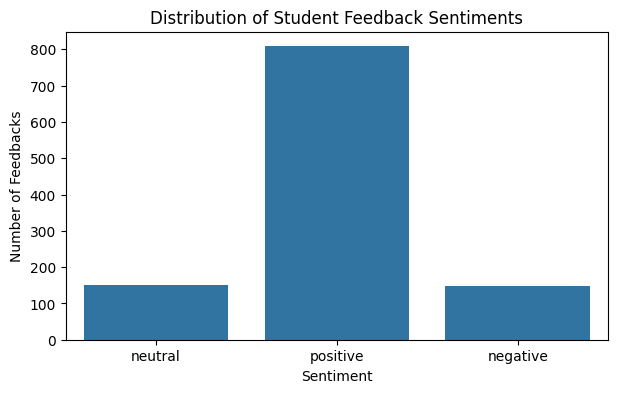

In [ ]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=feedback_df,
    x="sentiment"
)

plt.title(
    "Distribution of Student Feedback Sentiments"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Feedbacks")

plt.show()

### Visualize Feedback Categories Distribution

A horizontal bar plot is generated to visualize the distribution of feedbacks across different categories (e.g., 'Teaching', 'Course Content'). This helps in understanding which categories receive more feedback.

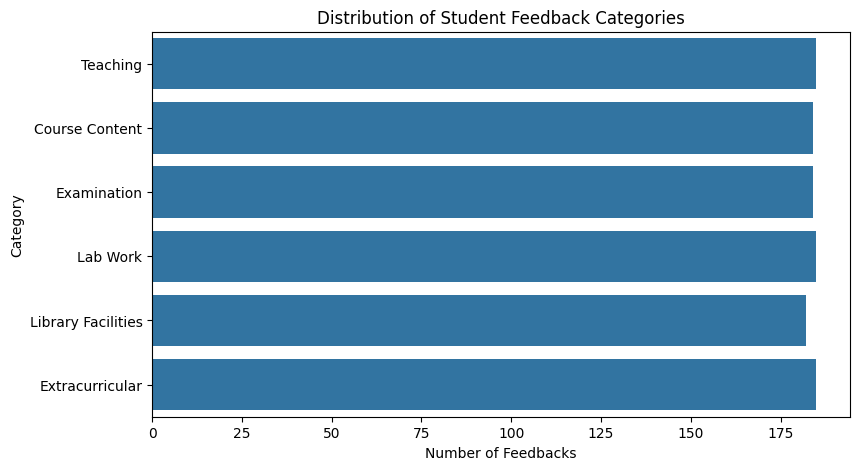

In [ ]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=feedback_df,
    y="category"
)

plt.title(
    "Distribution of Student Feedback Categories"
)

plt.xlabel("Number of Feedbacks")
plt.ylabel("Category")

plt.show()

### Define Text Preprocessing Function

A function `preprocess_text` is defined that performs several cleaning steps on text data: converting to lowercase, removing special characters and numbers, and removing extra spaces. This prepares the text for feature extraction.

In [ ]:
def preprocess_text(text):

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(
        r"[^a-zA-Z\s]",
        "",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

### Apply Text Preprocessing

The `preprocess_text` function is applied to the 'feedback' column of `feedback_df` to create a new 'clean_feedback' column. The original and cleaned feedback for the first 10 rows are then displayed to show the effect of preprocessing.

In [ ]:
feedback_df["clean_feedback"] = (
    feedback_df["feedback"]
    .apply(preprocess_text)
)

display(
    feedback_df[
        ["feedback", "clean_feedback"]
    ].head(10)
)

,feedback,clean_feedback
0,teacher are punctual but they should also give...,teacher are punctual but they should also give...
1,Good,good
2,Excellent lectures are delivered by teachers a...,excellent lectures are delivered by teachers a...
3,Good,good
4,teachers give us all the information required ...,teachers give us all the information required ...
5,Yes,yes
6,good and punctual,good and punctual
7,It is good,it is good
8,Good,good
9,Good,good


### Prepare Data for Modeling

The cleaned feedback text (`clean_feedback`) is separated into `X` (features) and the sentiment labels (`sentiment`) into `y` (target variable). The shapes of `X` and `y` are then printed to confirm their dimensions.

In [ ]:
X = feedback_df["clean_feedback"]

y = feedback_df["sentiment"]

print("Input X:", X.shape)
print("Target y:", y.shape)

Input X: (1105,)
Target y: (1105,)


### Split Data into Training and Testing Sets

The `X` and `y` data are split into training and testing sets using `train_test_split`. A `test_size` of 20% is used, and `stratify=y` ensures that the proportion of sentiment labels is maintained in both sets. The number of samples in the training and testing sets are then printed.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 884
Testing samples: 221


### TF-IDF Vectorization

A `TfidfVectorizer` is initialized to convert text feedback into numerical features. It fits the vectorizer on the training data (`X_train`) and transforms both the training and testing data (`X_train` and `X_test`). The shape of the resulting TF-IDF matrices are then printed.

In [ ]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print(
    "Training TF-IDF Shape:",
    X_train_tfidf.shape
)

print(
    "Testing TF-IDF Shape:",
    X_test_tfidf.shape
)

Training TF-IDF Shape: (884, 844)
Testing TF-IDF Shape: (221, 844)


### Train Logistic Regression Model

A `LogisticRegression` model is initialized and then trained using the TF-IDF transformed training data (`X_train_tfidf`) and corresponding training sentiment labels (`y_train`). A confirmation is printed upon successful training.

In [ ]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_tfidf,
    y_train
)

print("Model training completed successfully!")

Model training completed successfully!


### Make Predictions

The trained Logistic Regression model is used to make sentiment predictions on the TF-IDF transformed testing data (`X_test_tfidf`). A confirmation message is printed after the predictions are made.

In [ ]:
y_pred = model.predict(
    X_test_tfidf
)

print("Prediction completed successfully!")

Prediction completed successfully!


### Calculate Accuracy Score

The accuracy of the model's predictions is calculated by comparing the predicted sentiment labels (`y_pred`) with the actual sentiment labels (`y_test`). The accuracy is then printed as a percentage.

In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

Accuracy: 79.64 %


### Calculate Detailed Performance Metrics

Precision, recall, and F1-score for the model's predictions are calculated, in addition to accuracy. These metrics are calculated with `average='weighted'` to account for class imbalance. The results are printed as percentages.

In [ ]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1-Score :", round(f1 * 100, 2), "%")

Accuracy : 79.64 %
Precision: 77.96 %
Recall   : 79.64 %
F1-Score : 76.2 %


### Display Classification Report

A detailed classification report is generated and printed, which includes precision, recall, f1-score, and support for each sentiment class ('negative', 'neutral', 'positive'). This provides a comprehensive overview of the model's performance per class.

In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

    negative       0.75      0.31      0.44        29
     neutral       0.64      0.30      0.41        30
    positive       0.81      0.98      0.89       162

    accuracy                           0.80       221
   macro avg       0.73      0.53      0.58       221
weighted avg       0.78      0.80      0.76       221



### Plot Confusion Matrix

A confusion matrix is calculated and visualized. The heatmap shows the counts of true positive, true negative, false positive, and false negative predictions for each sentiment class, providing insight into where the model is performing well and where it is making errors.

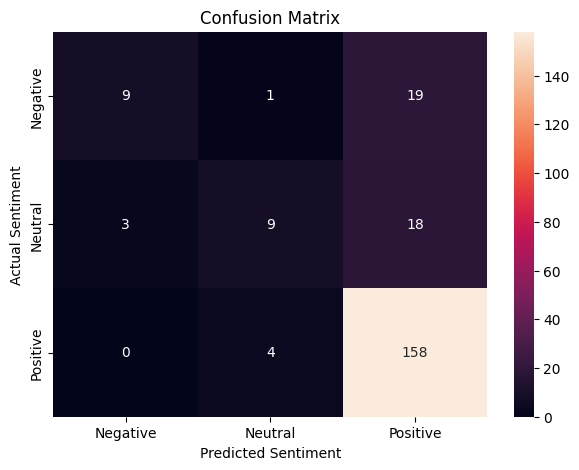

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[
        "negative",
        "neutral",
        "positive"
    ]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Negative",
        "Neutral",
        "Positive"
    ],
    yticklabels=[
        "Negative",
        "Neutral",
        "Positive"
    ]
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Sentiment")

plt.ylabel("Actual Sentiment")

plt.show()

### Analyze Category Sentiment Cross-Tabulation

A cross-tabulation table is created showing the distribution of sentiments across different feedback categories. It counts how many 'negative', 'neutral', and 'positive' feedbacks belong to each category.

In [ ]:
category_sentiment = pd.crosstab(
    feedback_df["category"],
    feedback_df["sentiment"]
)

print(category_sentiment)

sentiment           negative  neutral  positive
category                                       
Course Content            30       26       128
Examination               24       30       130
Extracurricular           12       19       154
Lab Work                  37       16       132
Library Facilities        31       24       127
Teaching                  13       35       137


### Visualize Sentiment Distribution Across Categories

A bar plot is generated based on the `category_sentiment` cross-tabulation. It visually represents the count of different sentiments within each feedback category, making it easy to compare sentiment distributions across categories.

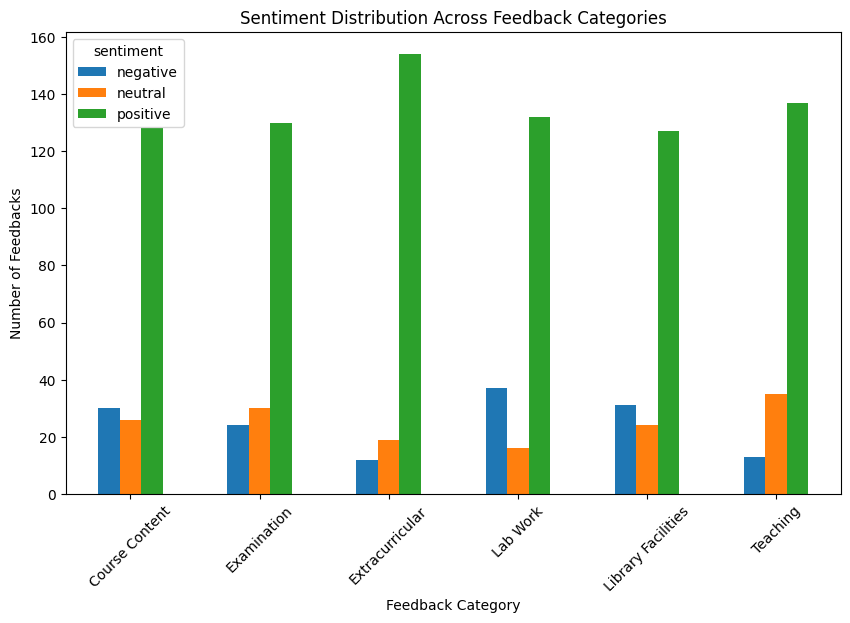

In [ ]:
category_sentiment.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Sentiment Distribution Across Feedback Categories"
)

plt.xlabel("Feedback Category")

plt.ylabel("Number of Feedbacks")

plt.xticks(rotation=45)

plt.show()

### Define Prediction Function

A function `predict_sentiment` is defined that takes a raw feedback string as input. It first preprocesses the text using the `preprocess_text` function, then transforms it using the trained TF-IDF vectorizer, and finally uses the Logistic Regression model to predict the sentiment.

In [ ]:
def predict_sentiment(feedback):

    cleaned_text = preprocess_text(
        feedback
    )

    text_vector = tfidf.transform(
        [cleaned_text]
    )

    prediction = model.predict(
        text_vector
    )[0]

    return prediction

### Interactive Sentiment Prediction

The user is prompted to enter student feedback. The `predict_sentiment` function is then used to predict the sentiment of the entered feedback, and the result is printed. This allows for interactive testing of the trained model.

In [ ]:
feedback = input(
    "Enter student feedback: "
)

prediction = predict_sentiment(
    feedback
)

print(
    "\nPredicted Sentiment:",
    prediction
)

Enter student feedback: The teachers explain concepts clearly and provide good practical knowledge.

Predicted Sentiment: positive


### Test Predictions with Sample Feedbacks

A list of `test_feedbacks` is defined and then iterated through. For each feedback, the `predict_sentiment` function is called, and both the original feedback and its predicted sentiment are printed, demonstrating the model's performance on new, unseen examples.

In [ ]:
test_feedbacks = [

    "The teachers explain concepts very clearly and provide useful examples.",

    "The laboratory facilities are poor and the equipment needs improvement.",

    "The course content is average and can be improved."
]

for text in test_feedbacks:

    prediction = predict_sentiment(text)

    print("Feedback:", text)

    print(
        "Predicted Sentiment:",
        prediction
    )

    print("-" * 70)

Feedback: The teachers explain concepts very clearly and provide useful examples.
Predicted Sentiment: positive
----------------------------------------------------------------------
Feedback: The laboratory facilities are poor and the equipment needs improvement.
Predicted Sentiment: negative
----------------------------------------------------------------------
Feedback: The course content is average and can be improved.
Predicted Sentiment: neutral
----------------------------------------------------------------------


### Identify Top Words for Each Sentiment

The top 10 most influential words (features) for each sentiment class ('negative', 'neutral', 'positive') are extracted from the trained Logistic Regression model's coefficients. These words are then printed for each class, providing insight into which terms are strongly associated with each sentiment.

In [ ]:
feature_names = np.array(
    tfidf.get_feature_names_out()
)

for i, class_name in enumerate(
    model.classes_
):

    top_indices = np.argsort(
        model.coef_[i]
    )[-10:]

    print(
        "\nTop words for:",
        class_name.upper()
    )

    print(
        feature_names[top_indices]
    )


Top words for: NEGATIVE
['insufficient' 'marks' 'improvement' 'available' 'equipments' 'given'
 'required' 'strict' 'time' 'books']

Top words for: NEUTRAL
['subjects' 'examinations' 'know' 'punctuality' 'interaction' 'teaching'
 'paper' 'checking' 'dont' 'average']

Top words for: POSITIVE
['punctual' 'satisfied' 'yes' 'way' 'perfect' 'ok' 'university' 'best'
 'excellent' 'good']


### Save Model and TF-IDF Vectorizer

The `pickle` module is used to save both the trained Logistic Regression model (`model`) and the fitted TF-IDF vectorizer (`tfidf`) to disk. This allows for the models to be reloaded and used later without retraining. A confirmation message is printed upon successful saving.

In [ ]:
import pickle

with open(
    "college_feedback_model.pkl",
    "wb"
) as file:

    pickle.dump(
        model,
        file
    )

with open(
    "tfidf_vectorizer.pkl",
    "wb"
) as file:

    pickle.dump(
        tfidf,
        file
    )

print(
    "Model and TF-IDF vectorizer saved successfully!"
)

Model and TF-IDF vectorizer saved successfully!


### Display Model Summary

A summary of the 'College Feedback Intelligence System' is printed, including the total number of feedback samples, training samples, testing samples, the model used (TF-IDF + Logistic Regression), and the key performance metrics (Accuracy, Precision, Recall, F1-Score) of the model.

In [ ]:
print("=" * 55)

print(
    "COLLEGE FEEDBACK INTELLIGENCE SYSTEM"
)

print("=" * 55)

print(
    "Total Feedback Samples:",
    len(feedback_df)
)

print(
    "Training Samples:",
    len(X_train)
)

print(
    "Testing Samples:",
    len(X_test)
)

print(
    "\nModel: TF-IDF + Logistic Regression"
)

print("\nPerformance:")

print(
    "Accuracy :",
    round(accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(precision * 100, 2),
    "%"
)

print(
    "Recall   :",
    round(recall * 100, 2),
    "%"
)

print(
    "F1-Score :",
    round(f1 * 100, 2),
    "%"
)

print("=" * 55)

COLLEGE FEEDBACK INTELLIGENCE SYSTEM
Total Feedback Samples: 1105
Training Samples: 884
Testing Samples: 221

Model: TF-IDF + Logistic Regression

Performance:
Accuracy : 79.64 %
Precision: 77.96 %
Recall   : 79.64 %
F1-Score : 76.2 %
